# Globe, projections and great-circle routes

Inspired by **Equal Earth Map**, credited to stevwang.dev in the
[Awesome Astra catalog](https://github.com/magiccreator-ai/awesome-gpt-6-astra#equal-earth-map).
[Creator post](https://x.com/stevwangdev/status/2096983019294974011) ·
[Creator demo](https://your-equal-earth.pages.dev/) ·
[Our 3D globe](https://jltobias.github.io/JupyterLite-Astra-demos/demos/?scene=globe)

**Learn:** why flattening a sphere changes scale, and why a shortest route can look curved.
**Predict:** will a one-degree longitude interval have the same ground length at 0° and 60° latitude?
We use a unit sphere, graticule and bundled **Natural Earth 1:110 million land outlines**
([public-domain source](https://github.com/nvkelso/natural-earth-vector/blob/693f11422f4e08d2da4566b854dda53eb7c39fb3/geojson/ne_110m_land.geojson)).
These generalized coastlines are real geography, not survey detail. City positions are rounded
teaching coordinates. Equal Earth formulas follow the
[PROJ reference](https://proj.org/en/stable/operations/projections/eqearth.html).


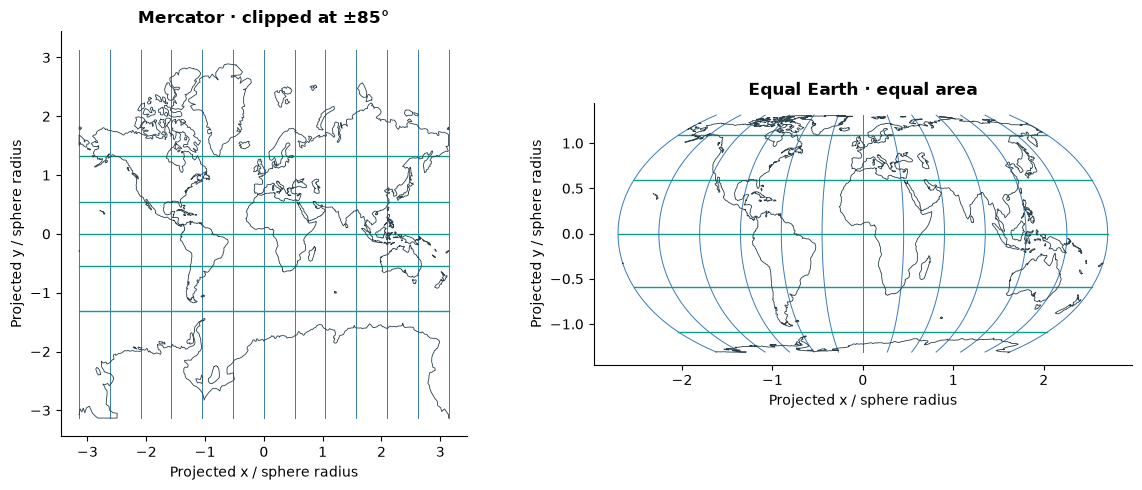

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from astra_utils import style
style()

land = json.loads(Path('data/ne_110m_land.geojson').read_text(encoding='utf-8'))
coastlines = []
for feature in land['features']:
    geometry = feature['geometry']
    polygons = [geometry['coordinates']] if geometry['type'] == 'Polygon' else geometry['coordinates']
    coastlines.extend(np.asarray(ring) for polygon in polygons for ring in polygon)

def equal_earth(lon, lat):
    """Longitude/latitude in radians; projected coordinates on a unit sphere."""
    a1, a2, a3, a4 = 1.340264, -0.081106, 0.000893, 0.003796
    theta = np.arcsin(np.sqrt(3) / 2 * np.sin(lat))
    t2 = theta**2
    denominator = 3 * (a1 + 3*a2*t2 + t2**3*(7*a3 + 9*a4*t2))
    return 2*np.sqrt(3)*lon*np.cos(theta)/denominator, theta*(a1+a2*t2+t2**3*(a3+a4*t2))

def mercator(lon, lat):
    lat = np.clip(lat, np.deg2rad(-85), np.deg2rad(85))
    return lon, np.log(np.tan(np.pi/4 + lat/2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, projection, name in zip(axes, [mercator, equal_earth], ['Mercator · clipped at ±85°', 'Equal Earth · equal area']):
    for lon in range(-180, 181, 30):
        lat = np.deg2rad(np.linspace(-85, 85, 181))
        ax.plot(*projection(np.full_like(lat, np.deg2rad(lon)), lat), color='#397ab9', lw=.7)
    for lat in range(-60, 61, 30):
        lon = np.deg2rad(np.linspace(-180, 180, 181))
        ax.plot(*projection(lon, np.full_like(lon, np.deg2rad(lat))), color='#0f9d92', lw=1)
    for ring in coastlines:
        lon,lat = np.deg2rad(ring.T)
        px,py = projection(lon,lat)
        # Break antimeridian jumps instead of drawing across the whole flat map.
        jumps = np.r_[False, np.abs(np.diff(ring[:,0])) > 180]
        px = np.where(jumps,np.nan,px)
        ax.plot(px,py,color='#263f49',lw=.6)
    ax.set(title=name, aspect='equal', xlabel='Projected x / sphere radius', ylabel='Projected y / sphere radius')
fig.tight_layout()
plt.show()


**Read the grid:** Mercator spreads parallels apart toward the poles. Equal Earth preserves area
but changes shapes and angles. Neither picture preserves every property of the sphere.
At 60° latitude, the ground length of a longitude interval is half its equatorial length because
parallel circumference scales with cos(latitude). Latitude and longitude are not Cartesian meters.

Convert longitude λ and latitude φ to `(cos φ cos λ, cos φ sin λ, sin φ)`.
Spherical linear interpolation follows the great-circle arc between two unit vectors.


Spherical route distance: 10,849 km (mean-radius Earth approximation)


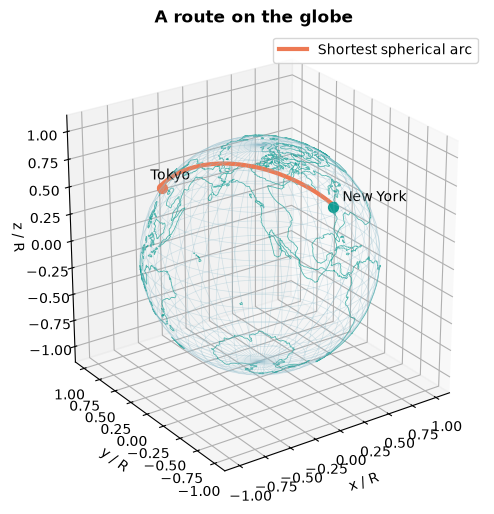

In [2]:
def xyz(lon_deg, lat_deg):
    lon, lat = np.deg2rad([lon_deg, lat_deg])
    return np.array([np.cos(lat)*np.cos(lon), np.cos(lat)*np.sin(lon), np.sin(lat)])

def great_circle(a, b, count=100):
    omega = np.arccos(np.clip(a @ b, -1, 1))
    if omega < 1e-10:
        return np.repeat(a[None], count, axis=0)
    if abs(np.pi - omega) < 1e-7:
        raise ValueError('Antipodal endpoints need an explicitly chosen great-circle plane.')
    t = np.linspace(0, 1, count)[:, None]
    return (np.sin((1-t)*omega)*a + np.sin(t*omega)*b) / np.sin(omega)

a, b = xyz(-74.0, 40.7), xyz(139.7, 35.7)  # New York, Tokyo (approximate)
route = great_circle(a, b)
angle = np.arccos(a @ b)
print(f'Spherical route distance: {6371 * angle:,.0f} km (mean-radius Earth approximation)')
u, v = np.meshgrid(np.linspace(0, 2*np.pi, 48), np.linspace(-np.pi/2, np.pi/2, 25))
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d')
ax.plot_wireframe(np.cos(v)*np.cos(u), np.cos(v)*np.sin(u), np.sin(v), color='#91bdcc', alpha=.35, lw=.5)
for ring in coastlines:
    ax.plot(*(xyz(*ring.T)*1.004),color='#0f9d92',lw=.6,alpha=.7)
ax.plot(*(route*1.02).T, color='#ed7953', lw=3, label='Shortest spherical arc')
for point, name in [(a, 'New York'), (b, 'Tokyo')]:
    ax.scatter(*point, s=50)
    ax.text(*(point*1.12), name)
ax.set(xlabel='x / R', ylabel='y / R', zlabel='z / R', title='A route on the globe')
ax.set_box_aspect((1, 1, 1))
ax.view_init(25, -125)
ax.legend()
plt.show()
assert np.allclose(np.linalg.norm(route, axis=1), 1)
assert np.allclose(route[[0, -1]], [a, b])


**Try → compare → explain:** replace Tokyo with London `(-0.1, 51.5)`. Predict the distance
before running. Then increase the graticule density: does more detail improve your understanding?

**Transfer:** a flat-map line and a globe route answer different geometric questions.
This notebook omits ellipsoidal geodesics, terrain clearance and actual flight constraints.
